<a href="https://colab.research.google.com/github/kirankumariq201/aquasignal/blob/main/Copy_of_aquasignal_explore.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# AquaSignal - Day 1
# Step 1: Install what we need

!pip install pandas numpy matplotlib seaborn scikit-learn xgboost shap -q
print("All libraries installed ✅")

All libraries installed ✅


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/water_potability.csv')

print("Dataset loaded ✅")
print("Shape:", df.shape)
df.head()

Dataset loaded ✅
Shape: (3276, 10)


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [ ]:
# Step 3: Understand what we're working with

print("=== COLUMN NAMES ===")
print(df.columns.tolist())

print("\n=== DATA TYPES ===")
print(df.dtypes)

print("\n=== BASIC STATISTICS ===")
df.describe()

=== COLUMN NAMES ===
['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity', 'Potability']

=== DATA TYPES ===
ph                 float64
Hardness           float64
Solids             float64
Chloramines        float64
Sulfate            float64
Conductivity       float64
Organic_carbon     float64
Trihalomethanes    float64
Turbidity          float64
Potability           int64
dtype: object

=== BASIC STATISTICS ===


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


In [ ]:
# Step 4: Check for missing values

print("=== MISSING VALUES ===")
missing = df.isnull().sum()
print(missing)

print("\n=== MISSING PERCENTAGE ===")
missing_percent = (df.isnull().sum() / len(df)) * 100
print(missing_percent.round(2))

print("\n=== SAFE vs UNSAFE WATER ===")
print(df['Potability'].value_counts())
print("\n0 = Unsafe ❌  |  1 = Safe ✅")

=== MISSING VALUES ===
ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

=== MISSING PERCENTAGE ===
ph                 14.99
Hardness            0.00
Solids              0.00
Chloramines         0.00
Sulfate            23.84
Conductivity        0.00
Organic_carbon      0.00
Trihalomethanes     4.95
Turbidity           0.00
Potability          0.00
dtype: float64

=== SAFE vs UNSAFE WATER ===
Potability
0    1998
1    1278
Name: count, dtype: int64

0 = Unsafe ❌  |  1 = Safe ✅


In [ ]:
# Step 5: Fill missing values with median
# We use MEDIAN not MEAN because water data has outliers

df['ph'] = df['ph'].fillna(df['ph'].median())
df['Sulfate'] = df['Sulfate'].fillna(df['Sulfate'].median())
df['Trihalomethanes'] = df['Trihalomethanes'].fillna(df['Trihalomethanes'].median())

# Verify no missing values remain
print("=== MISSING VALUES AFTER FIX ===")
print(df.isnull().sum())
print("\nData is clean and ready ✅")

=== MISSING VALUES AFTER FIX ===
ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64

Data is clean and ready ✅


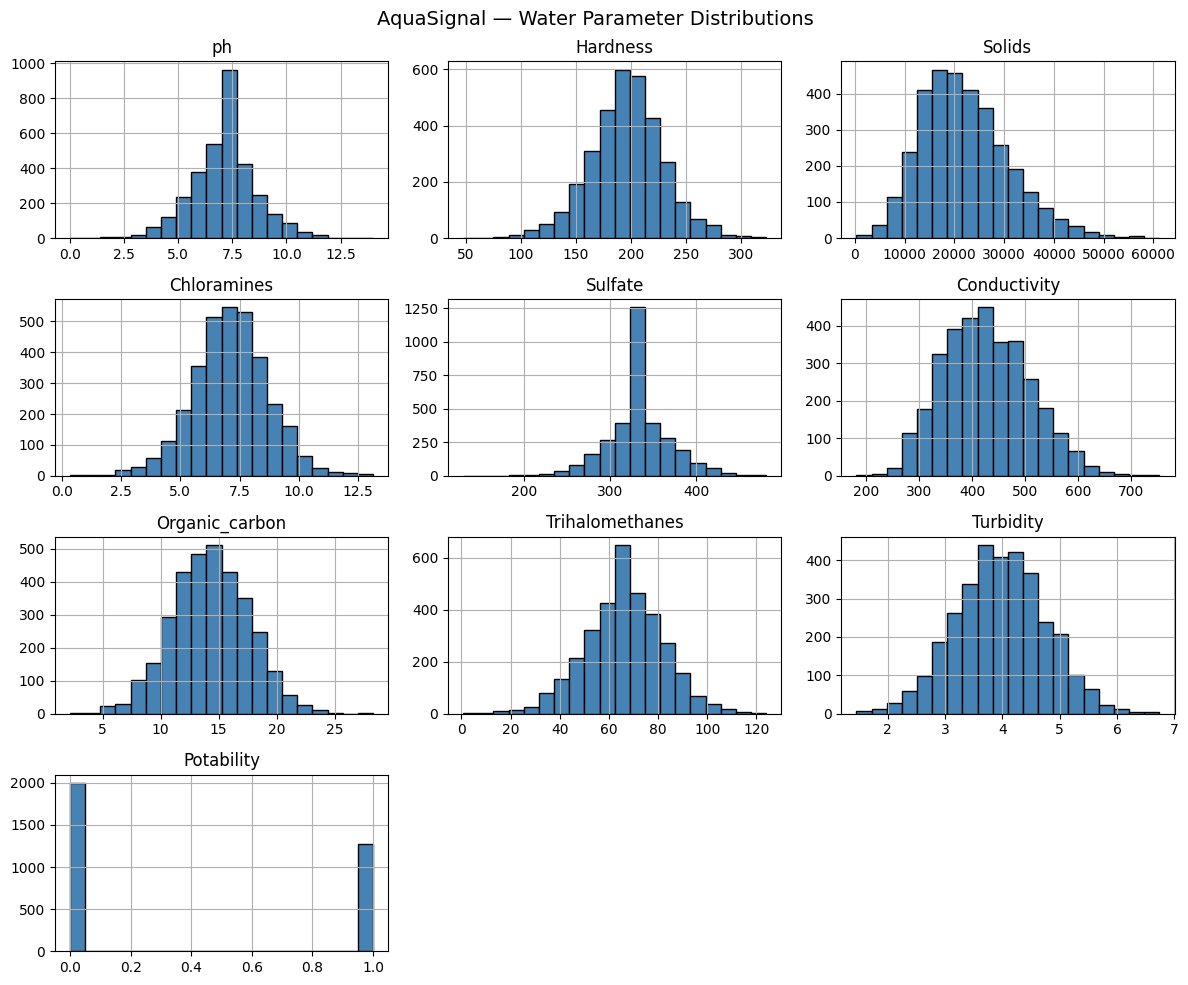

In [ ]:
# Step 6: Visualize the data

import matplotlib.pyplot as plt
import seaborn as sns

# Plot distribution of each feature
df.hist(figsize=(12, 10), bins=20, color='steelblue', edgecolor='black')
plt.suptitle('AquaSignal — Water Parameter Distributions', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# EDA Observation 1:
# Solids is right skewed — extreme outliers exist in contaminated sources
# Potability is imbalanced — 1998 unsafe vs 1278 safe samples
# All other parameters show normal distribution — data is reliable

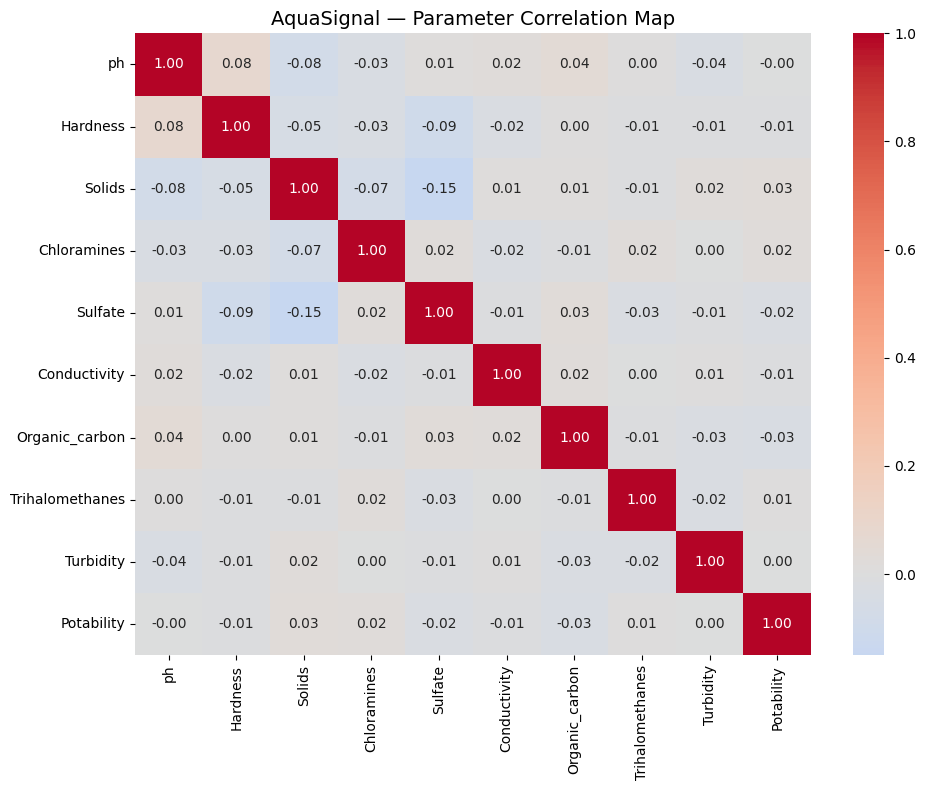

In [ ]:
# Step 7: Correlation Heatmap
# Which parameters actually influence water safety?

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(),
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0)
plt.title('AquaSignal — Parameter Correlation Map', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# EDA Observation 3:
# Correlation heatmap confirms — ALL parameters have near-zero
# correlation with Potability (max 0.03)
# Parameters are also independent from each other (no multicollinearity)
# This is a non-linear problem — perfect use case for ensemble ML models
# like Random Forest and XGBoost

In [ ]:
# Step 8: Split data into Features and Target

X = df.drop('Potability', axis=1)  # Everything except the answer
y = df['Potability']               # The answer we want to predict

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeatures (what model learns from):")
print(X.columns.tolist())
print("\nTarget (what model predicts):")
print(y.value_counts())

Features shape: (3276, 9)
Target shape: (3276,)

Features (what model learns from):
['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity']

Target (what model predicts):
Potability
0    1998
1    1278
Name: count, dtype: int64


In [ ]:
# Step 9: Fix imbalance + Train/Test Split

from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Split — 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Fix imbalance using SMOTE
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(pd.Series(y_train_balanced).value_counts())

print("\nTest set size:", X_test.shape[0])
print("Training set size:", X_train_balanced.shape[0])

Before SMOTE:
Potability
0    1598
1    1022
Name: count, dtype: int64

After SMOTE:
Potability
0    1598
1    1598
Name: count, dtype: int64

Test set size: 656
Training set size: 3196


In [ ]:
# EDA Observation 4:
# SMOTE balanced training data from 1598/1022 to 1598/1598
# Created 576 synthetic safe water samples
# Test set kept original distribution — 656 unseen samples
# This ensures honest model evaluation

In [ ]:
# Step 10: Train Random Forest Model

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Train the model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_balanced, y_train_balanced)

# Evaluate on test set
y_pred = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("=== RANDOM FOREST RESULTS ===")
print(f"Accuracy: {accuracy*100:.2f}%")
print("\nDetailed Report:")
print(classification_report(y_test, y_pred,
      target_names=['Unsafe', 'Safe']))

=== RANDOM FOREST RESULTS ===
Accuracy: 65.09%

Detailed Report:
              precision    recall  f1-score   support

      Unsafe       0.70      0.75      0.72       400
        Safe       0.56      0.50      0.53       256

    accuracy                           0.65       656
   macro avg       0.63      0.62      0.63       656
weighted avg       0.65      0.65      0.65       656



In [ ]:
# Model Observation 1:
# Random Forest baseline: 65% accuracy
# Recall for Safe class only 0.50 — misses half of safe water
# Need better model — trying XGBoost next
# Asymmetric risk noted — false negatives on Unsafe class = dangerous

In [ ]:
# Step 11: Train XGBoost Model

from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train_balanced, y_train_balanced)

y_pred_xgb = xgb_model.predict(X_test)
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)

print("=== XGBOOST RESULTS ===")
print(f"Accuracy: {accuracy_xgb*100:.2f}%")
print("\nDetailed Report:")
print(classification_report(y_test, y_pred_xgb,
      target_names=['Unsafe', 'Safe']))

print("\n=== MODEL COMPARISON ===")
print(f"Random Forest: 65.09%")
print(f"XGBoost:       {accuracy_xgb*100:.2f}%")

=== XGBOOST RESULTS ===
Accuracy: 64.79%

Detailed Report:
              precision    recall  f1-score   support

      Unsafe       0.71      0.72      0.72       400
        Safe       0.55      0.53      0.54       256

    accuracy                           0.65       656
   macro avg       0.63      0.63      0.63       656
weighted avg       0.65      0.65      0.65       656


=== MODEL COMPARISON ===
Random Forest: 65.09%
XGBoost:       64.79%


In [ ]:
# Model Observation 2:
# XGBoost: 64.79% — slightly worse than Random Forest
# Both models plateau around 65%
# Root cause: weak feature correlation confirmed by heatmap
# This is a data limitation, not a model limitation
# Solution: feature engineering + hyperparameter tuning
# We keep Random Forest as our primary model

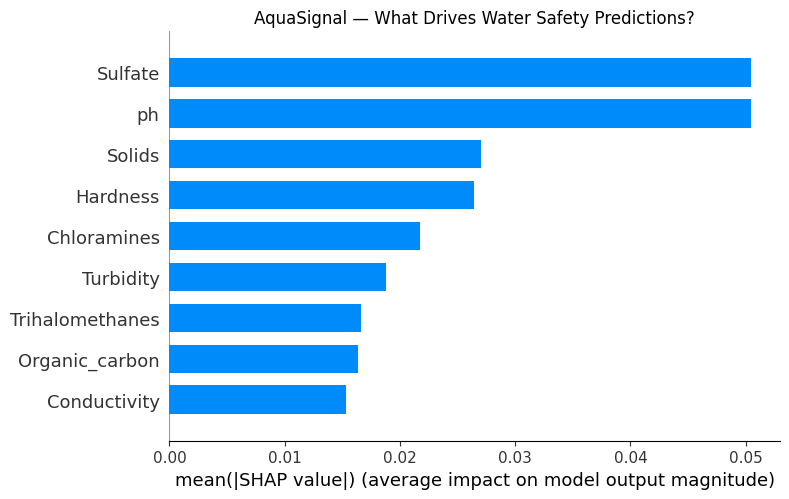

In [ ]:
# Step 12: SHAP — Why does our model make each decision?

import shap

# Create explainer
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

# Plot feature importance
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values[:,:,1],
                  X_test,
                  plot_type="bar",
                  show=False)
plt.title("AquaSignal — What Drives Water Safety Predictions?")
plt.tight_layout()
plt.show()

In [ ]:
# Model Observation 3:
# SHAP reveals Sulfate and pH as top prediction drivers (~0.05)
# Contradicts heatmap which showed near-zero linear correlation
# Proves non-linear relationships exist in water safety data
# This is AquaSignal's core scientific insight
# Simple statistics would have missed this completely